In [2]:
import pandas as pd

# Definindo os caminhos exatos dos arquivos dentro do seu Google Drive
caminho_order = '/content/drive/MyDrive/Colab Notebooks/SuperStone/superstore_order.csv'
caminho_shipping = '/content/drive/MyDrive/Colab Notebooks/SuperStone/superstore_shipping.csv'

# Carregando as tabelas e tratando possíveis problemas de codificação (encoding)
try:
    df_order = pd.read_csv(caminho_order, encoding='utf-8')
    df_shipping = pd.read_csv(caminho_shipping, encoding='utf-8')
    print("Sucesso: Tabelas carregadas usando encoding UTF-8!")
except UnicodeDecodeError:
    df_order = pd.read_csv(caminho_order, encoding='latin1')
    df_shipping = pd.read_csv(caminho_shipping, encoding='latin1')
    print("Sucesso: Tabelas carregadas usando encoding Latin1!")

Sucesso: Tabelas carregadas usando encoding UTF-8!


In [ ]:
# Unindo as tabelas de pedidos e envios através de um Left Join usando chave composta
df_final = pd.merge(df_order, df_shipping, on=['order_id', 'product_id'], how='left')

print("Merge executado com sucesso! A tabela unificada 'df_final' foi criada.")

Merge executado com sucesso! A tabela unificada 'df_final' foi criada.


In [3]:
df_final = pd.merge(df_order, df_shipping, on=['order_id', 'product_id'], how='left')

In [ ]:
# 1. Verificando o formato (linhas, colunas) das tabelas envolvidas
print(f"Formato da tabela df_order original: {df_order.shape}")
print(f"Formato da tabela df_shipping original: {df_shipping.shape}")
print(f"Formato da nova tabela df_final: {df_final.shape}")
print("-" * 60)

# 2. Visualizando as primeiras 5 linhas do DataFrame unificado
print("Amostra dos dados unificados (df_final):")
df_final.head()

Formato da tabela df_order original: (19960, 15)
Formato da tabela df_shipping original: (19960, 5)
Formato da nova tabela df_final: (19992, 18)
------------------------------------------------------------
Amostra dos dados unificados (df_final):


,category,city,customer_ID,customer_name,discount,order_id,order_priority,product_id,product_name,profit,quantity,segment,order_date,Sales,country,ship_mode,shipping_cost,ship_date
0,Office Supplies,Aba,DW-34801,Dianna Wilson,0.70,NI-2011-6340,Medium,OFF-BOS-10001348,"Boston Pencil Sharpener, Water Color",-90.174,14,Home Office,2023-04-16 00:00:00.000000 UTC,NaN,Nigeria,Standard Class,10.61,2023-04-21 00:00:00.000000 UTC
1,Office Supplies,Pescara,AH-101952,Alan Haines,0.00,ES-2011-4993245,Medium,OFF-AR-10002382,"Binney & Smith Pencil Sharpener, Water Color",49.560,4,Corporate,2023-04-08 00:00:00.000000 UTC,108.0,Italy,Standard Class,9.00,2023-04-12 00:00:00.000000 UTC
2,Furniture,Pescara,AH-101952,Alan Haines,0.00,ES-2011-4993245,Medium,FUR-FU-10004640,"Tenex Light Bulb, Durable",7.560,4,Corporate,2023-04-08 00:00:00.000000 UTC,64.0,Italy,Standard Class,3.57,2023-04-12 00:00:00.000000 UTC
3,Office Supplies,Pescara,RH-195102,Rick Huthwaite,0.40,ES-2011-1702658,Medium,OFF-ST-10001974,"Rogers File Cart, Industrial",-32.580,1,Home Office,2023-09-30 00:00:00.000000 UTC,85.0,Italy,Standard Class,5.09,2023-10-04 00:00:00.000000 UTC
4,Office Supplies,Banda Aceh,MF-176651,Maureen Fritzler,0.27,ID-2011-49031,Medium,OFF-AR-10004138,"Stanley Pens, Easy-Erase",4.068,5,Corporate,2023-03-25 00:00:00.000000 UTC,38.0,Indonesia,Standard Class,2.52,2023-03-29 00:00:00.000000 UTC


In [ ]:
# Agrupando os dados unificados por categoria para extrair as métricas de negócio
analise_categoria = df_final.groupby('category').agg(
    Total_Vendas=('Sales', 'sum'),
    Lucro_Total=('profit', 'sum'),
    Media_Custo_Envio=('shipping_cost', 'mean'),
    Quantidade_Itens=('quantity', 'sum')
).reset_index()

# Exibindo os resultados formatados
print("--- Análise Estratégica por Categoria de Produto ---")
analise_categoria

--- Análise Estratégica por Categoria de Produto ---


,category,Total_Vendas,Lucro_Total,Media_Custo_Envio,Quantidade_Itens
0,Furniture,1617024.0,112009.06280,45.074973,13606
1,Office Supplies,1474743.0,190325.22010,12.755981,42208
2,Technology,1856019.0,257054.70814,50.324766,13868


In [ ]:
# Analisando o impacto do modo de envio no lucro e nas vendas
analise_logistica = df_final.groupby('ship_mode').agg(
    Total_Vendas=('Sales', 'sum'),
    Lucro_Total=('profit', 'sum'),
    Media_Custo_Envio=('shipping_cost', 'mean'),
    Total_Pedidos=('order_id', 'count')
).reset_index()

print("--- Análise de Logística por Modo de Envio ---")
analise_logistica

--- Análise de Logística por Modo de Envio ---


,ship_mode,Total_Vendas,Lucro_Total,Media_Custo_Envio,Total_Pedidos
0,First Class,706609.0,74430.20322,41.936044,2948
1,Same Day,259129.0,33971.43642,43.879625,1028
2,Second Class,953355.0,103847.22784,29.863676,3907
3,Standard Class,3028693.0,347140.12356,20.089372,12109


In [ ]:
# Analisando o comportamento de compra por segmento de cliente
analise_segmento = df_final.groupby('segment').agg(
    Total_Vendas=('Sales', 'sum'),
    Lucro_Total=('profit', 'sum'),
    Media_Desconto=('discount', 'mean'),
    Media_Quantidade=('quantity', 'mean')
).reset_index()

print("--- Análise de Comportamento por Segmento de Cliente ---")
analise_segmento

--- Análise de Comportamento por Segmento de Cliente ---


,segment,Total_Vendas,Lucro_Total,Media_Desconto,Media_Quantidade
0,Consumer,2646844.0,285674.38900,0.145323,3.500143
1,Corporate,1467107.0,175446.21566,0.140636,3.485382
2,Home Office,833835.0,98268.38638,0.147193,3.441236


In [ ]:
# Analisando o desempenho geográfico (Top 10 Países em Vendas)
analise_geografia = df_final.groupby('country').agg(
    Total_Vendas=('Sales', 'sum'),
    Lucro_Total=('profit', 'sum'),
    Total_Custo_Envio=('shipping_cost', 'sum'),
    Media_Custo_Envio=('shipping_cost', 'mean')
).sort_values(by='Total_Vendas', ascending=False).head(10).reset_index()

print("--- Top 10 Países: Análise de Vendas vs Custos Logísticos ---")
analise_geografia

--- Top 10 Países: Análise de Vendas vs Custos Logísticos ---


,country,Total_Vendas,Lucro_Total,Total_Custo_Envio,Media_Custo_Envio
0,United States,955062.0,111242.02920,100015.4965,24.399975
1,Australia,341036.0,43050.49200,35302.7100,33.494032
2,France,320380.0,41470.41600,36041.4700,34.555580
3,China,285935.0,59415.15600,31276.2200,40.671287
4,Mexico,271012.0,43797.90316,28205.9490,26.634513
5,Germany,265036.0,44438.88900,26432.8000,30.347646
6,India,232892.0,47367.30000,24657.9800,40.824470
7,United Kingdom,210961.0,47714.53200,20653.2000,32.120062
8,Indonesia,155389.0,4221.16380,16662.6140,31.203397
9,Brazil,148597.0,12687.78964,15424.6850,24.999489


In [ ]:
# Gerando o resumo estatístico detalhado para Sales e profit
resumo_numerico = df_order[['Sales', 'profit']].describe()

# Exibindo o resumo na tela
resumo_numerico

,Sales,profit
count,19938.000000,19960.000000
mean,247.468853,27.873552
std,491.488088,162.404489
min,1.000000,-3701.892800
25%,31.000000,0.000000
50%,85.000000,9.291420
75%,252.000000,36.720000
max,22638.000000,4630.475500


In [ ]:
# 1. Calculando os Quartis Q1 (25%) e Q3 (75%) para o lucro
Q1 = df_order['profit'].quantile(0.25)
Q3 = df_order['profit'].quantile(0.75)

# 2. Calculando a Distância Interquartil (IQR)
IQR = Q3 - Q1

# 3. Definindo os Limites Aceitáveis (Inferior e Superior)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Exibindo os resultados na tela
print(f"--- Limites Estatísticos do Lucro (Profit) ---")
print(f"Q1 (25% dos dados ganham até): {Q1:.2f}")
print(f"Q3 (75% dos dados ganham até): {Q3:.2f}")
print(f"IQR (Amplitude do meio): {IQR:.2f}")
print(f"Limite Inferior (Abaixo disso é prejuízo atípico): {limite_inferior:.2f}")
print(f"Limite Superior (Acima disso é lucro atípico): {limite_superior:.2f}")

--- Limites Estatísticos do Lucro (Profit) ---
Q1 (25% dos dados ganham até): 0.00
Q3 (75% dos dados ganham até): 36.72
IQR (Amplitude do meio): 36.72
Limite Inferior (Abaixo disso é prejuízo atípico): -55.08
Limite Superior (Acima disso é lucro atípico): 91.80


In [ ]:
# Isolando as linhas que estão fora dos limites calculados
df_outliers_profit = df_order.loc[(df_order['profit'] > limite_superior) | (df_order['profit'] < limite_inferior)]

# Contando quantas linhas se encaixam como outliers
total_outliers = len(df_outliers_profit)

print(f"Quantidade de registros com lucro/prejuízo atípico na SuperStore: {total_outliers}")
print("\nVeja uma amostra desses registros atípicos:")
df_outliers_profit[['customer_name', 'category', 'Sales', 'profit', 'quantity']].head(10)

Quantidade de registros com lucro/prejuízo atípico na SuperStore: 3857

Veja uma amostra desses registros atípicos:


,customer_name,category,Sales,profit,quantity
0,Dianna Wilson,Office Supplies,NaN,-90.174,14
10,Erica Hackney,Furniture,64.0,-62.118,2
14,Lori Olson,Furniture,185.0,-83.478,1
15,Lori Olson,Office Supplies,46.0,-67.176,2
23,Emily Phan,Furniture,132.0,-55.992,4
24,Emily Phan,Technology,61.0,-89.088,4
25,Charles Crestani,Office Supplies,114.0,-111.168,4
26,Charles Crestani,Office Supplies,77.0,-116.136,4
27,Charles Crestani,Technology,172.0,-107.832,4
30,Patrick O'Donnell,Office Supplies,83.0,-157.086,2


In [ ]:
# Esse comando vai exibir as 5 primeiras linhas da tabela de pedidos
df_order.head()

,category,city,customer_ID,customer_name,discount,order_id,order_priority,product_id,product_name,profit,quantity,segment,order_date,Sales,country
0,Office Supplies,Aba,DW-34801,Dianna Wilson,0.70,NI-2011-6340,Medium,OFF-BOS-10001348,"Boston Pencil Sharpener, Water Color",-90.174,14,Home Office,2023-04-16 00:00:00.000000 UTC,NaN,Nigeria
1,Office Supplies,Pescara,AH-101952,Alan Haines,0.00,ES-2011-4993245,Medium,OFF-AR-10002382,"Binney & Smith Pencil Sharpener, Water Color",49.560,4,Corporate,2023-04-08 00:00:00.000000 UTC,108.0,Italy
2,Furniture,Pescara,AH-101952,Alan Haines,0.00,ES-2011-4993245,Medium,FUR-FU-10004640,"Tenex Light Bulb, Durable",7.560,4,Corporate,2023-04-08 00:00:00.000000 UTC,64.0,Italy
3,Office Supplies,Pescara,RH-195102,Rick Huthwaite,0.40,ES-2011-1702658,Medium,OFF-ST-10001974,"Rogers File Cart, Industrial",-32.580,1,Home Office,2023-09-30 00:00:00.000000 UTC,85.0,Italy
4,Office Supplies,Banda Aceh,MF-176651,Maureen Fritzler,0.27,ID-2011-49031,Medium,OFF-AR-10004138,"Stanley Pens, Easy-Erase",4.068,5,Corporate,2023-03-25 00:00:00.000000 UTC,38.0,Indonesia


In [ ]:
# Mostra o resumo da tabela de pedidos (tipos de dados e contagem de preenchidos)
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19960 entries, 0 to 19959
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   category        19960 non-null  object 
 1   city            19960 non-null  object 
 2   customer_ID     19960 non-null  object 
 3   customer_name   19960 non-null  object 
 4   discount        19960 non-null  float64
 5   order_id        19960 non-null  object 
 6   order_priority  19960 non-null  object 
 7   product_id      19960 non-null  object 
 8   product_name    19960 non-null  object 
 9   profit          19960 non-null  float64
 10  quantity        19960 non-null  int64  
 11  segment         19960 non-null  object 
 12  order_date      19960 non-null  object 
 13  Sales           19938 non-null  float64
 14  country         19960 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 2.3+ MB


In [ ]:
df_shipping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19960 entries, 0 to 19959
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       19960 non-null  object 
 1   product_id     19960 non-null  object 
 2   ship_mode      19960 non-null  object 
 3   shipping_cost  19960 non-null  float64
 4   ship_date      19960 non-null  object 
dtypes: float64(1), object(4)
memory usage: 779.8+ KB


In [ ]:
# Filtrando o DataFrame para exibir apenas as 22 linhas onde a coluna 'Sales' está nula
linhas_com_sales_nulo = df_order[df_order['Sales'].isnull()]

# Mostrando essas linhas na tela
linhas_com_sales_nulo

,category,city,customer_ID,customer_name,discount,order_id,order_priority,product_id,product_name,profit,quantity,segment,order_date,Sales,country
0,Office Supplies,Aba,DW-34801,Dianna Wilson,0.70,NI-2011-6340,Medium,OFF-BOS-10001348,"Boston Pencil Sharpener, Water Color",-90.1740,14,Home Office,2023-04-16 00:00:00.000000 UTC,NaN,Nigeria
1950,Office Supplies,Dakar,HM-48601,Harry Marie,0.00,SG-2011-8430,Critical,OFF-TEN-10004194,"Tenex File Cart, Single Width",63.2400,1,Corporate,2023-08-03 00:00:00.000000 UTC,NaN,Senegal
2186,Office Supplies,Dublin,CL-118902,Carl Ludwig,0.50,IT-2011-1152860,Medium,OFF-ST-10003153,"Tenex File Cart, Single Width",-8.1300,2,Consumer,2023-06-06 00:00:00.000000 UTC,NaN,Ireland
2273,Office Supplies,Harrow,AA-104802,Andrew Allen,0.00,ES-2011-3002504,High,OFF-ST-10003153,"Tenex File Cart, Single Width",63.2400,1,Consumer,2023-12-08 00:00:00.000000 UTC,NaN,United Kingdom
4085,Office Supplies,Masjed Soleyman,RE-94502,Richard Eichhorn,0.00,IR-2011-6620,Medium,OFF-TEN-10004194,"Tenex File Cart, Single Width",63.2400,1,Consumer,2023-11-07 00:00:00.000000 UTC,NaN,Iran
4129,Office Supplies,Kinshasa,TB-116251,Trudy Brown,0.00,CG-2011-6250,Medium,OFF-TEN-10004194,"Tenex File Cart, Single Width",63.2400,1,Consumer,2023-02-15 00:00:00.000000 UTC,NaN,Democratic Republic of the Congo
5147,Office Supplies,Nakhon Ratchasima,CM-122351,Chris McAfee,0.47,ID-2011-12596,Medium,OFF-ST-10002066,"Smead File Cart, Blue",-45.9018,2,Consumer,2023-01-03 00:00:00.000000 UTC,NaN,Thailand
5366,Furniture,Wollongong,PL-189251,Paul Lucas,0.10,ID-2011-23215,Medium,FUR-CH-10002932,"Harbour Creations Rocking Chair, Adjustable",-0.0180,1,Home Office,2023-12-11 00:00:00.000000 UTC,NaN,Australia
6712,Office Supplies,Cairns,PS-187601,Pamela Stobb,0.40,IN-2011-12967,Medium,OFF-AP-10002128,"Breville Toaster, White",22.4100,3,Consumer,2023-05-10 00:00:00.000000 UTC,NaN,Australia
7781,Technology,Medan,MA-175601,Matt Abelman,0.17,IN-2011-54155,Medium,TEC-MA-10002471,"Epson Phone, Durable",53.4894,2,Home Office,2023-08-12 00:00:00.000000 UTC,NaN,Indonesia


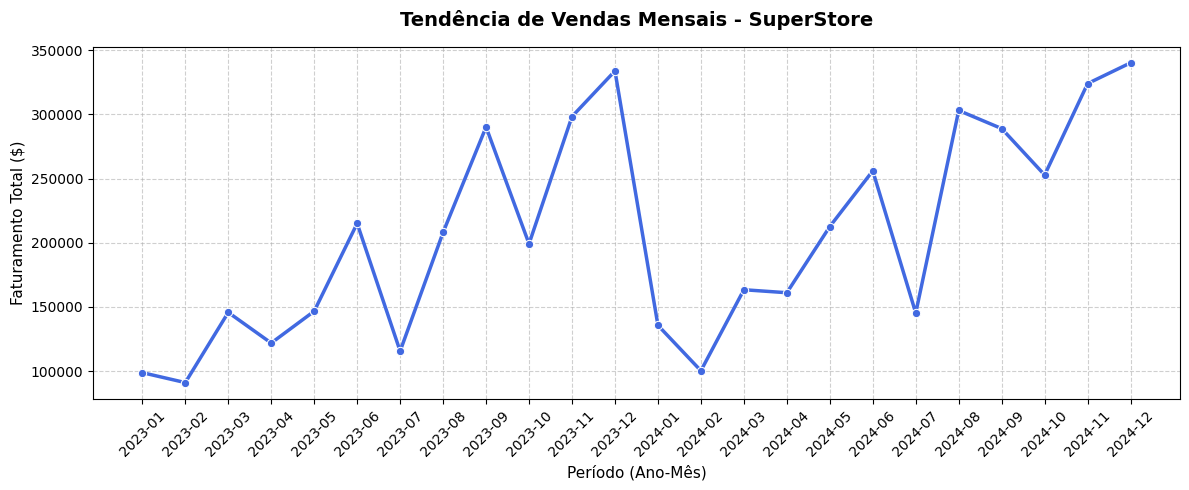

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Garantindo que a data está no formato correto e criando a coluna Ano-Mês de forma limpa (sem Warning)
df_final['order_date'] = pd.to_datetime(df_final['order_date'])
df_final['ano_mes'] = df_final['order_date'].dt.strftime('%Y-%m')

# 2. Agrupando as vendas por mês
vendas_tempo = df_final.groupby('ano_mes')['Sales'].sum().reset_index().sort_values('ano_mes')

# 3. Construindo o Gráfico de Linhas
plt.figure(figsize=(12, 5))
sns.lineplot(data=vendas_tempo, x='ano_mes', y='Sales', marker='o', color='royalblue', linewidth=2.5)

# Configurações visuais de clareza (Títulos e Rótulos)
plt.title('Tendência de Vendas Mensais - SuperStore', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Período (Ano-Mês)', fontsize=11)
plt.ylabel('Faturamento Total ($)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Exibindo o gráfico na tela
plt.show()

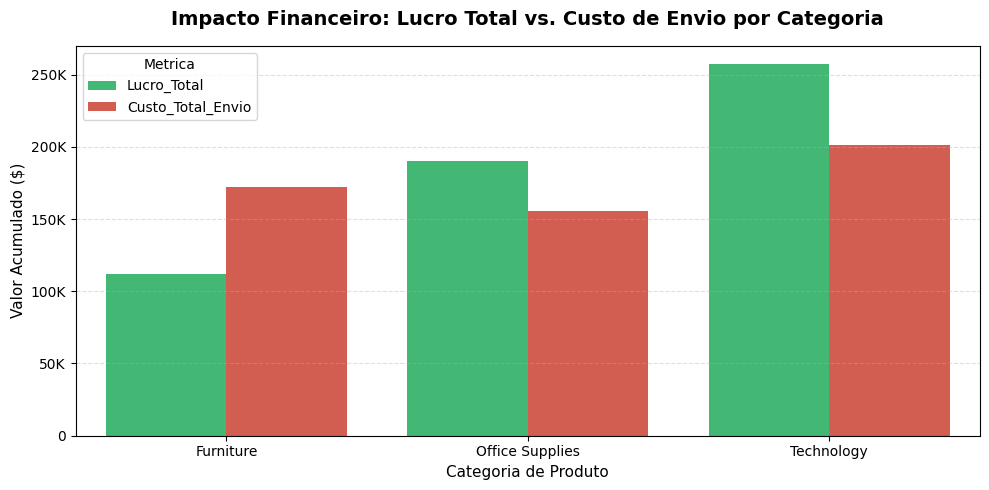

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 1. Definindo a função de formatação para K (Milhares)
def milhares_formatter(x, pos):
    return f'{x*1e-3:.0f}K' if x != 0 else '0'

# 2. Preparando os dados unificados
dados_grafico2 = df_final.groupby('category').agg(
    Lucro_Total=('profit', 'sum'),
    Custo_Total_Envio=('shipping_cost', 'sum')
).reset_index()

# 3. Transformando para o formato longo necessário para o Seaborn
dados_longo = pd.melt(dados_grafico2, id_vars='category', value_vars=['Lucro_Total', 'Custo_Total_Envio'],
                      var_name='Metrica', value_name='Valor')

# 4. Construindo o Gráfico com as cores corretas
plt.figure(figsize=(10, 5))
sns.barplot(data=dados_longo, x='category', y='Valor', hue='Metrica', palette=['#2ecc71', '#e74c3c'])

# 5. Aplicando a formatação exata no eixo Y para K (Ex: 250K)
plt.gca().yaxis.set_major_formatter(FuncFormatter(milhares_formatter))

# Configurações visuais de clareza
plt.title('Impacto Financeiro: Lucro Total vs. Custo de Envio por Categoria', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoria de Produto', fontsize=11)
plt.ylabel('Valor Acumulado ($)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

# Exibindo o gráfico corrigido
plt.show()

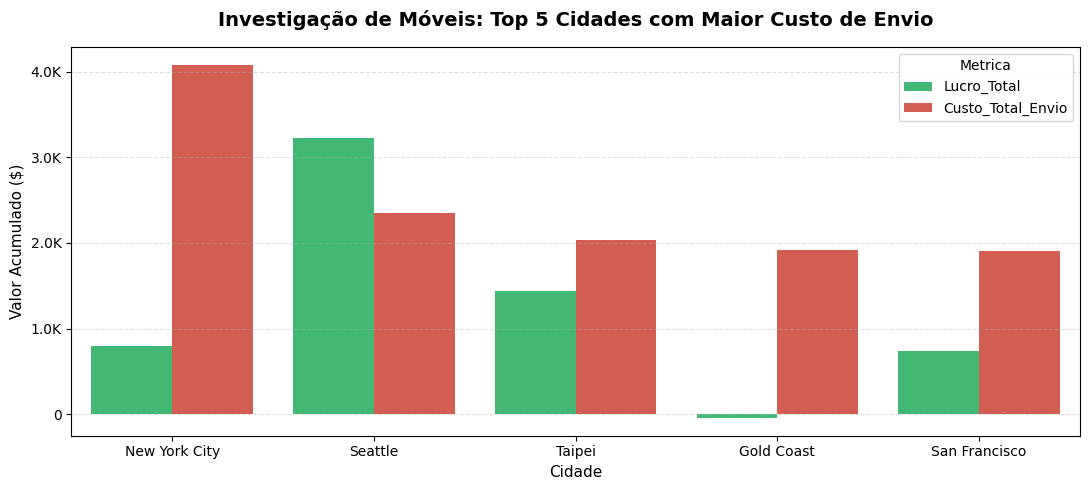

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 1. Função de formatação para milhares (K)
def milhares_formatter(x, pos):
    return f'{x*1e-3:.1f}K' if x != 0 else '0'

# 2. Filtrando a base apenas para a categoria de Furniture (Móveis)
df_furniture = df_final[df_final['category'] == 'Furniture']

# 3. Agrupando pelas Top 5 Cidades com maior Custo de Envio em Móveis
analise_cidade_furniture = df_furniture.groupby('city').agg(
    Lucro_Total=('profit', 'sum'),
    Custo_Total_Envio=('shipping_cost', 'sum')
).sort_values(by='Custo_Total_Envio', ascending=False).head(5).reset_index()

# 4. Transformando o formato para formato longo (melt)
cidade_longo = pd.melt(analise_cidade_furniture, id_vars='city', value_vars=['Lucro_Total', 'Custo_Total_Envio'],
                    var_name='Metrica', value_name='Valor')

# 5. Construindo o gráfico de comparação por Cidade
plt.figure(figsize=(11, 5))
sns.barplot(data=cidade_longo, x='city', y='Valor', hue='Metrica', palette=['#2ecc71', '#e74c3c'])

# Configurações visuais e aplicação do formato K no eixo Y
plt.gca().yaxis.set_major_formatter(FuncFormatter(milhares_formatter))
plt.title('Investigação de Móveis: Top 5 Cidades com Maior Custo de Envio', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cidade', fontsize=11)
plt.ylabel('Valor Acumulado ($)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

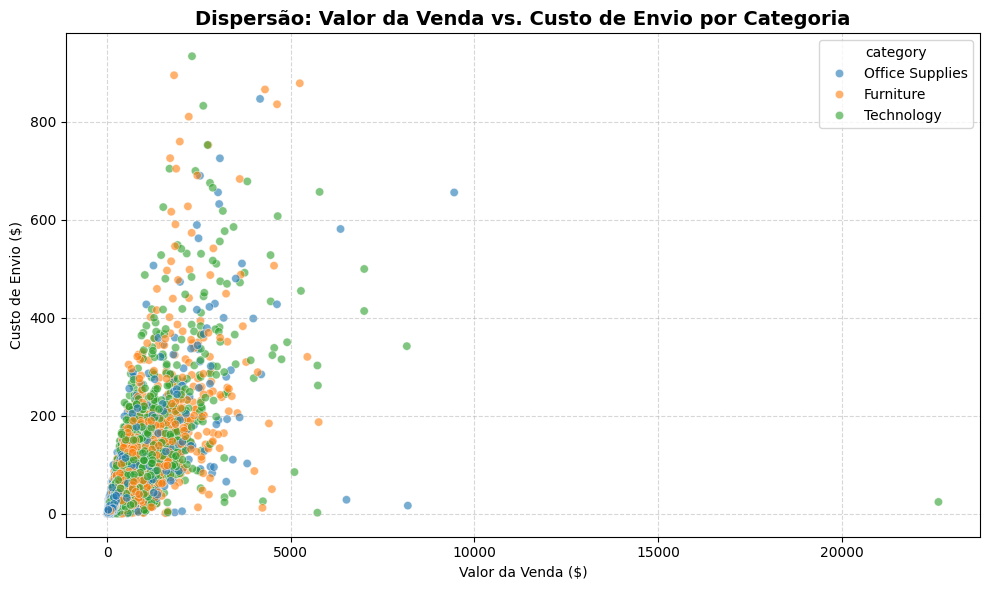

In [ ]:
# Gráfico de Dispersão: Correlação entre Valor da Venda e Custo de Envio
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='Sales', y='shipping_cost', hue='category', alpha=0.6)

plt.title('Dispersão: Valor da Venda vs. Custo de Envio por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Valor da Venda ($)')
plt.ylabel('Custo de Envio ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df_final.to_csv('superstore_limpo_final.csv', index=False)

In [ ]:
# Listando todas as colunas disponíveis para encontrar o nome exato
print(df_final.columns.tolist())

['category', 'city', 'customer_ID', 'customer_name', 'discount', 'order_id', 'order_priority', 'product_id', 'product_name', 'profit', 'quantity', 'segment', 'order_date', 'Sales', 'country', 'ship_mode', 'shipping_cost', 'ship_date', 'ano_mes']


In [ ]:
# Contando linhas 100% idênticas na tabela de pedidos
duplicados_completos_order = df_order.duplicated().sum()

# Contando linhas 100% idênticas na tabela de frete
duplicados_completos_shipping = df_shipping.duplicated().sum()

print(f"Linhas 100% duplicadas em df_order: {duplicados_completos_order}")
print(f"Linhas 100% duplicadas em df_shipping: {duplicados_completos_shipping}")

Linhas 100% duplicadas em df_order: 5
Linhas 100% duplicadas em df_shipping: 0


In [ ]:
# Removendo as 5 linhas duplicadas e salvando a alteração na própria tabela (inplace=True)
df_order.drop_duplicates(inplace=True)

# Verificando se elas sumiram mesmo (o resultado agora deve ser 0)
print(f"Agora existem {df_order.duplicated().sum()} linhas duplicadas em df_order.")

Agora existem 0 linhas duplicadas em df_order.


In [ ]:
# Listando os valores únicos da coluna de categorias
categorias_originais = df_order['category'].unique()
print("Categorias encontradas na base:")
print(categorias_originais)
print("-" * 50)

# Listando os valores únicos da coluna de segmentos
segmentos_originais = df_order['segment'].unique()
print("Segmentos encontrados na base:")
print(segmentos_originais)

Categorias encontradas na base:
['Office Supplies' 'Furniture' 'Technology']
--------------------------------------------------
Segmentos encontrados na base:
['Home Office' 'Corporate' 'Consumer']


In [ ]:
# Limpando e padronizando a coluna 'category'
df_order['category'] = df_order['category'].astype(str).str.lower().str.strip()

# Limpando e padronizando a coluna 'segment'
df_order['segment'] = df_order['segment'].astype(str).str.lower().str.strip()

print("Padronização aplicada com sucesso!")

Padronização aplicada com sucesso!


In [ ]:
# Verificando como ficaram as categorias após a limpeza
print("Categorias após a padronização:")
print(df_order['category'].unique())
print("-" * 50)

# Verificando como ficaram os segmentos após a limpeza
print("Segmentos após a padronização:")
print(df_order['segment'].unique())

Categorias após a padronização:
['office supplies' 'furniture' 'technology']
--------------------------------------------------
Segmentos após a padronização:
['home office' 'corporate' 'consumer']


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
